<a href="https://colab.research.google.com/github/ArtIC-TITECH/b3-proj-2026/blob/main/theme_G/theme_G.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# テーマG：Looped LLMの再帰回数と精度・収束性の関係

## 目的

Ouro-1.4Bの再帰回数を1〜8回に変え、計算量を増やすことで予測性能が改善するか、また出力分布と潜在表現が固定点へ近づくかを評価する。

- **独立変数**：再帰回数
- **統制変数**：16bit重み、評価データ、系列長、復号方法
- **性能指標**：Perplexity、next-token accuracy
- **収束指標**：隣接step間のJS divergence、予測token変更率、hidden state相対変化
- **振動の補助指標**：2 step前の予測へ戻る割合

有限個の入力・有限回の観測で数学的な収束を証明することはできない。ここでは「収束・発散・飽和・振動のどの傾向と整合するか」を実験的に議論する。


## 環境セットアップ

Colabで「ランタイム」→「ランタイムのタイプを変更」→ **T4 GPU** を選ぶ。次のセルでパッケージが更新された場合だけ、セッションを再起動して先頭から実行する。


In [1]:
# Ouroの固定revisionに合わせ、Transformers周辺だけ互換版へ揃えます。
# torch / CUDAはColab標準環境をそのまま使います。
import sys
import subprocess
from importlib.metadata import version, PackageNotFoundError
import torch

if not torch.cuda.is_available():
    raise RuntimeError("ランタイムのタイプをGPU（T4）に変更してください。")

TARGETS = {
    "transformers": "4.55.0",
    "tokenizers": "0.21.4",
    "huggingface-hub": "0.36.2",
    "accelerate": "1.10.0",
    "safetensors": "0.6.2",
    "Pillow": "11.3.0",
}

needs_install = []
for pkg, wanted in TARGETS.items():
    try:
        current = version(pkg)
    except PackageNotFoundError:
        current = None
    if current != wanted:
        needs_install.append(f"{pkg}=={wanted}")

RESTART_REQUIRED = bool(needs_install)
if needs_install:
    print("互換パッケージをインストールします:", needs_install)
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--no-cache-dir", "--upgrade", "--force-reinstall",
            "--no-deps", "--only-binary=:all:", *needs_install,
        ],
        check=True,
    )
    print("\nインストール完了。『ランタイム』→『セッションを再起動』を1回実行してください。")
    print("再起動後は、このNotebookを先頭から実行してください。")
else:
    print("環境OK:", torch.__version__, torch.cuda.get_device_name(0))


環境OK: 2.11.0+cu130 Tesla T4


## モジュールの読み込み・GPU確認


In [2]:
import gc
import math
import time
from importlib.metadata import version, PackageNotFoundError

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image, ImageDraw

if globals().get("RESTART_REQUIRED", False):
    raise RuntimeError("パッケージ更新後です。ランタイムを再起動して先頭から実行してください。")

required_versions = {
    "transformers": "4.55.0",
    "tokenizers": "0.21.4",
    "huggingface-hub": "0.36.2",
    "accelerate": "1.10.0",
    "safetensors": "0.6.2",
}
for pkg, wanted in required_versions.items():
    try:
        current = version(pkg)
    except PackageNotFoundError:
        current = None
    if current != wanted:
        raise RuntimeError(f"{pkg}={current!r} です。環境セットアップを再実行してください。")

ImageDraw.Draw(Image.new("RGB", (8, 8))).point((0, 0))

from datasets import load_dataset
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

device = "cuda:0"
capability = torch.cuda.get_device_capability(0)
dtype = torch.bfloat16 if capability[0] >= 8 and torch.cuda.is_bf16_supported() else torch.float16
BASELINE_LABEL = "BF16" if dtype == torch.bfloat16 else "FP16"

print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__, "Transformers:", version("transformers"))
print("Model dtype:", BASELINE_LABEL)


GPU: Tesla T4
PyTorch: 2.11.0+cu130 Transformers: 4.55.0
Model dtype: FP16


## 実験条件

実験前に、性能が最大になる再帰回数と、隣接step間の変化が縮小するかを予想する。再帰回数にほぼ比例して計算量が増える点も考慮する。


In [3]:
MODEL_ID = "ByteDance/Ouro-1.4B"
MODEL_REVISION = "574fa66cb8bf5abdc979642d01cf2b79b16bfab1"

# 独立変数：再帰回数。重み精度は16bitのまま固定する。
RECURRENT_STEPS = list(range(1, 9))
MAX_RECURRENT_STEPS = max(RECURRENT_STEPS)

SEQ_LEN = 256
NUM_SEQUENCES = 16       # 最終評価では32または64への増加を推奨
EVAL_BATCH_SIZE = 1

# JS divergenceは語彙全体を使うため、token位置を間引いて測る。
JS_POSITION_STRIDE = 8
JS_CHUNK_POSITIONS = 8

print("Recurrent sweep:", RECURRENT_STEPS)
print("Evaluation predictions:", SEQ_LEN * NUM_SEQUENCES)
print("JS probe positions/sequence:", math.ceil(SEQ_LEN / JS_POSITION_STRIDE))


Recurrent sweep: [1, 2, 3, 4, 5, 6, 7, 8]
Evaluation predictions: 4096
JS probe positions/sequence: 32


## Ouro-1.4Bの読み込みと中間状態の確認


In [4]:
globals().pop("model", None)
gc.collect()
torch.cuda.empty_cache()

config = AutoConfig.from_pretrained(
    MODEL_ID, revision=MODEL_REVISION, trust_remote_code=True,
)
config.total_ut_steps = MAX_RECURRENT_STEPS
config.use_cache = False
config.early_exit_threshold = None
config.early_exit_step = None

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID, revision=MODEL_REVISION, trust_remote_code=True,
)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    revision=MODEL_REVISION,
    config=config,
    trust_remote_code=True,
    torch_dtype=dtype,
    attn_implementation="eager",
    low_cpu_mem_usage=True,
).to(device)
model.eval()

# Ouroのbase modelにも最大再帰回数を同期する。
model.model.total_ut_steps = MAX_RECURRENT_STEPS
model.early_exit_threshold = None
model.early_exit_step = None

with torch.inference_mode():
    encoded = tokenizer("The sky is blue because", return_tensors="pt")
    base_out, hidden_states, gate_list = model.model(
        input_ids=encoded.input_ids.to(device),
        attention_mask=encoded.attention_mask.to(device),
        use_cache=False,
    )
    assert len(hidden_states) == MAX_RECURRENT_STEPS
    assert all(torch.isfinite(h).all() for h in hidden_states)
    print("Intermediate states:", len(hidden_states), "CUDA forward: OK")
    del encoded, base_out, hidden_states, gate_list
    torch.cuda.empty_cache()


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_ouro.py: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/825 [00:00<?, ?B/s]

modeling_ouro.py: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.87G [00:00<?, ?B/s]

Intermediate states: 8 CUDA forward: OK


## 評価データ：WikiText-2


In [5]:
dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split="test",
)
texts = [text for text in dataset["text"] if text.strip()]
all_text = "\n\n".join(texts)

tokens_per_sequence = SEQ_LEN + 1
needed_tokens = NUM_SEQUENCES * tokens_per_sequence
token_ids = tokenizer(
    all_text,
    return_tensors="pt",
    add_special_tokens=False,
    truncation=True,
    max_length=needed_tokens,
).input_ids[0]

if token_ids.numel() < needed_tokens:
    raise RuntimeError(f"評価用tokenが不足しています: {token_ids.numel()} < {needed_tokens}")

eval_tokens = token_ids[:needed_tokens].view(NUM_SEQUENCES, tokens_per_sequence)
print("eval_tokens:", tuple(eval_tokens.shape))


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

eval_tokens: (16, 257)


## 精度・収束・振動の評価

最大8回まで1度だけ再帰計算し、各stepのhidden stateへ同じ`lm_head`を適用する。これにより、各深さを別々にforwardするより条件を揃えて効率よく比較できる。

JS divergenceやhidden state相対変化がstepとともに小さくなれば固定点へ近づく傾向と整合する。一方、変化が拡大する場合は発散傾向、tokenが2 step前へ頻繁に戻る場合は周期2振動の可能性がある。


In [6]:
@torch.inference_mode()
def mean_js_divergence(logits_a, logits_b, stride=8, chunk_positions=8):
    """隣接stepの出力分布間の平均Jensen-Shannon divergence。"""
    a = logits_a[:, ::stride, :]
    b = logits_b[:, ::stride, :]
    total_js, total_positions = 0.0, 0

    for pos in range(0, a.shape[1], chunk_positions):
        aa = a[:, pos:pos + chunk_positions, :].float()
        bb = b[:, pos:pos + chunk_positions, :].float()
        log_p, log_q = F.log_softmax(aa, -1), F.log_softmax(bb, -1)
        p, q = log_p.exp(), log_q.exp()
        m = 0.5 * (p + q)
        log_m = torch.log(m.clamp_min(1e-12))
        js = 0.5 * (
            (p * (log_p - log_m)).sum(-1)
            + (q * (log_q - log_m)).sum(-1)
        )
        total_js += js.sum().item()
        total_positions += js.numel()

    return total_js, total_positions


@torch.inference_mode()
def evaluate_recurrence_sweep(model, eval_tokens, recurrent_steps, batch_size=1):
    """1回の最大深度forwardから、各再帰stepの精度と変化量を測る。"""
    max_steps = max(recurrent_steps)
    model.config.total_ut_steps = max_steps
    model.model.total_ut_steps = max_steps
    model.early_exit_threshold = None
    model.early_exit_step = None

    nll = {s: 0.0 for s in recurrent_steps}
    correct = {s: 0 for s in recurrent_steps}
    counts = {s: 0 for s in recurrent_steps}
    js_sum = {s: 0.0 for s in recurrent_steps if s > 1}
    js_count = {s: 0 for s in recurrent_steps if s > 1}
    flip_sum = {s: 0 for s in recurrent_steps if s > 1}
    flip_count = {s: 0 for s in recurrent_steps if s > 1}
    hidden_change_sum = {s: 0.0 for s in recurrent_steps if s > 1}
    hidden_count = {s: 0 for s in recurrent_steps if s > 1}
    lag2_sum = {s: 0 for s in recurrent_steps if s > 2}
    lag2_count = {s: 0 for s in recurrent_steps if s > 2}

    start_time = time.perf_counter()
    for start in range(0, len(eval_tokens), batch_size):
        batch = eval_tokens[start:start + batch_size].to(device)
        inputs, labels = batch[:, :-1], batch[:, 1:]
        base_out, hidden_states, gate_list = model.model(
            input_ids=inputs, use_cache=False
        )

        prev_logits = prev_hidden = prev_pred = pred_two_back = None
        for step in recurrent_steps:
            hidden = hidden_states[step - 1]
            logits = model.lm_head(hidden)
            if not torch.isfinite(logits).all():
                raise RuntimeError(f"step={step}: logitsにNaN/Infがあります")

            for pos in range(0, labels.shape[1], 32):
                scores = logits[:, pos:pos + 32, :].float()
                target = labels[:, pos:pos + 32]
                loss = F.cross_entropy(
                    scores.reshape(-1, scores.shape[-1]),
                    target.reshape(-1),
                    reduction="sum",
                )
                nll[step] += loss.item()
                correct[step] += (scores.argmax(-1) == target).sum().item()
                counts[step] += target.numel()

            pred = logits.argmax(-1)
            if prev_logits is not None:
                value, n_positions = mean_js_divergence(
                    prev_logits,
                    logits,
                    stride=JS_POSITION_STRIDE,
                    chunk_positions=JS_CHUNK_POSITIONS,
                )
                js_sum[step] += value
                js_count[step] += n_positions

                changed = pred != prev_pred
                flip_sum[step] += changed.sum().item()
                flip_count[step] += changed.numel()

                rel_change = torch.linalg.vector_norm(
                    hidden.float() - prev_hidden.float(), dim=-1
                ) / (torch.linalg.vector_norm(prev_hidden.float(), dim=-1) + 1e-8)
                hidden_change_sum[step] += rel_change.sum().item()
                hidden_count[step] += rel_change.numel()

            if pred_two_back is not None:
                returned = (pred == pred_two_back) & (pred != prev_pred)
                lag2_sum[step] += returned.sum().item()
                lag2_count[step] += returned.numel()

            prev_logits = logits
            prev_hidden = hidden
            pred_two_back = prev_pred
            prev_pred = pred

        del batch, inputs, labels, base_out, hidden_states, gate_list
        done = min(start + batch_size, len(eval_tokens))
        if done % 4 == 0 or done == len(eval_tokens):
            print(f"Evaluated {done}/{len(eval_tokens)}  {time.perf_counter()-start_time:.1f}s")

    rows = []
    for step in recurrent_steps:
        mean_nll = nll[step] / counts[step]
        rows.append({
            "recurrent_steps": step,
            "perplexity": math.exp(mean_nll) if mean_nll < 709 else float("inf"),
            "token_accuracy_pct": 100.0 * correct[step] / counts[step],
            "js_from_prev": js_sum[step] / js_count[step] if step > 1 else np.nan,
            "top1_flip_rate_pct": (
                100.0 * flip_sum[step] / flip_count[step] if step > 1 else np.nan
            ),
            "hidden_rel_change": (
                hidden_change_sum[step] / hidden_count[step] if step > 1 else np.nan
            ),
            "lag2_return_rate_pct": (
                100.0 * lag2_sum[step] / lag2_count[step] if step > 2 else np.nan
            ),
            "relative_compute": float(step),
        })
    return pd.DataFrame(rows)


## 再帰回数1〜8の比較


In [7]:
results_df = evaluate_recurrence_sweep(
    model,
    eval_tokens,
    RECURRENT_STEPS,
    batch_size=EVAL_BATCH_SIZE,
)

step4 = results_df.loc[results_df["recurrent_steps"] == 4].iloc[0]
results_df["ppl_ratio_vs_step4"] = results_df["perplexity"] / step4["perplexity"]
results_df["accuracy_delta_vs_step4_pp"] = (
    results_df["token_accuracy_pct"] - step4["token_accuracy_pct"]
)
results_df.to_csv("theme_G_recurrence_results.csv", index=False)
results_df.round(6)


Evaluated 4/16  1.9s
Evaluated 8/16  3.5s
Evaluated 12/16  5.1s
Evaluated 16/16  6.7s


,recurrent_steps,perplexity,token_accuracy_pct,js_from_prev,top1_flip_rate_pct,hidden_rel_change,lag2_return_rate_pct,relative_compute,ppl_ratio_vs_step4,accuracy_delta_vs_step4_pp
0,1,164.038285,32.861328,NaN,NaN,NaN,NaN,1.0,10.223042,-12.475586
1,2,26.573305,41.503906,0.258522,41.210938,1.237984,NaN,2.0,1.656077,-3.833008
2,3,17.025444,44.702148,0.080784,21.606445,0.557184,2.880859,3.0,1.061044,-0.634766
3,4,16.045936,45.336914,0.029487,10.791016,0.225839,2.197266,4.0,1.000000,0.000000
4,5,17.271187,43.579102,0.032315,14.013672,0.261856,2.612305,5.0,1.076359,-1.757812
5,6,17.224864,43.969727,0.017798,12.573242,0.228183,5.004883,6.0,1.073472,-1.367188
6,7,17.293357,44.165039,0.010251,7.641602,0.140327,2.075195,7.0,1.077741,-1.171875
7,8,17.388819,44.140625,0.015483,5.834961,0.099234,1.269531,8.0,1.083690,-1.196289


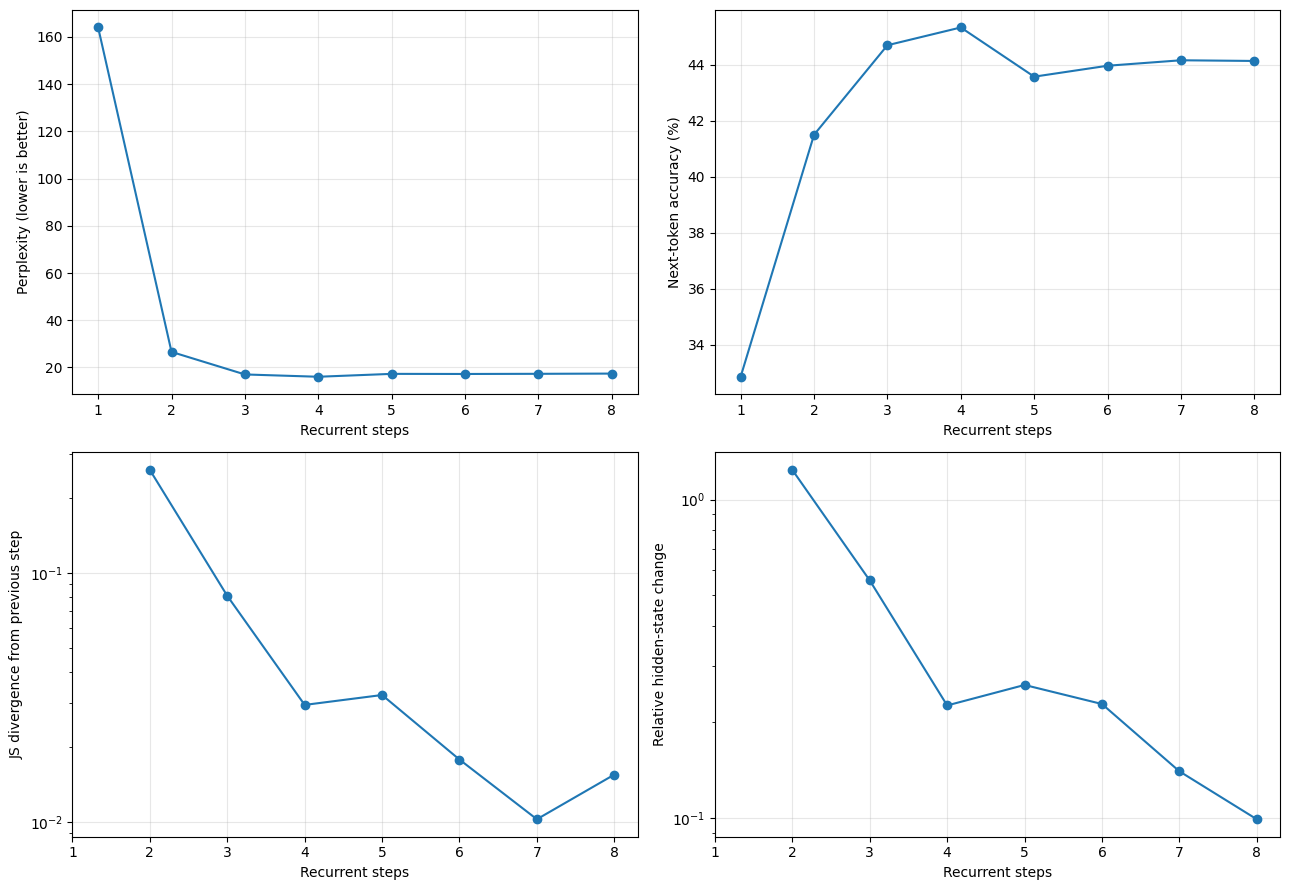

,recurrent_steps,top1_flip_rate_pct,lag2_return_rate_pct
0,1,NaN,NaN
1,2,41.2109,NaN
2,3,21.6064,2.8809
3,4,10.7910,2.1973
4,5,14.0137,2.6123
5,6,12.5732,5.0049
6,7,7.6416,2.0752
7,8,5.8350,1.2695


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(results_df["recurrent_steps"], results_df["perplexity"], marker="o")
axes[0, 0].set_ylabel("Perplexity (lower is better)")

axes[0, 1].plot(results_df["recurrent_steps"], results_df["token_accuracy_pct"], marker="o")
axes[0, 1].set_ylabel("Next-token accuracy (%)")

axes[1, 0].plot(results_df["recurrent_steps"], results_df["js_from_prev"], marker="o")
axes[1, 0].set_ylabel("JS divergence from previous step")
axes[1, 0].set_yscale("log")

axes[1, 1].plot(results_df["recurrent_steps"], results_df["hidden_rel_change"], marker="o")
axes[1, 1].set_ylabel("Relative hidden-state change")
axes[1, 1].set_yscale("log")

for ax in axes.flat:
    ax.set_xlabel("Recurrent steps")
    ax.set_xticks(RECURRENT_STEPS)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

results_df[[
    "recurrent_steps",
    "top1_flip_rate_pct",
    "lag2_return_rate_pct",
]].round(4)


In [9]:
def trend_summary(df, metric):
    """隣接step間の変化量が縮むかを補助的に要約する（収束の証明ではない）。"""
    values = df[metric].dropna().clip(lower=1e-12).to_numpy(float)
    ratios = values[1:] / values[:-1]
    geometric_ratio = float(np.exp(np.mean(np.log(ratios))))
    tendency = "縮小傾向" if geometric_ratio < 0.9 else (
        "拡大傾向" if geometric_ratio > 1.1 else "混合・飽和・振動の可能性"
    )
    return {"metric": metric, "geometric_ratio": geometric_ratio, "tendency": tendency}


summary_df = pd.DataFrame([
    trend_summary(results_df, "js_from_prev"),
    trend_summary(results_df, "hidden_rel_change"),
])

best_ppl = results_df.loc[results_df["perplexity"].idxmin()]
best_acc = results_df.loc[results_df["token_accuracy_pct"].idxmax()]
print("Minimum PPL step:", int(best_ppl["recurrent_steps"]))
print("Maximum accuracy step:", int(best_acc["recurrent_steps"]))
summary_df


Minimum PPL step: 4
Maximum accuracy step: 4


,metric,geometric_ratio,tendency
0,js_from_prev,0.625497,縮小傾向
1,hidden_rel_change,0.656635,縮小傾向


## 生成文の比較

step 1・4・8の生成を同じプロンプト、同じgreedy decodingで比較する。再帰回数を増やしたとき、正確さ・一貫性・冗長さがどう変わるか観察する。


In [10]:
def set_recurrent_steps(model, steps):
    model.config.total_ut_steps = int(steps)
    model.model.total_ut_steps = int(steps)
    model.config.early_exit_threshold = None
    model.config.early_exit_step = None
    model.early_exit_threshold = None
    model.early_exit_step = None


@torch.inference_mode()
def generate_at_depth(prompt, steps, max_new_tokens=32):
    set_recurrent_steps(model, steps)
    encoded = tokenizer(prompt, return_tensors="pt")
    ids = encoded.input_ids.to(device)
    mask = encoded.attention_mask.to(device)
    start = ids.shape[1]

    for _ in range(max_new_tokens):
        out = model(
            input_ids=ids,
            attention_mask=mask,
            use_cache=False,
            logits_to_keep=1,
        )
        next_id = out.logits[:, -1, :].argmax(-1, keepdim=True)
        ids = torch.cat([ids, next_id], dim=1)
        mask = torch.cat([mask, torch.ones_like(next_id)], dim=1)
        if tokenizer.eos_token_id is not None and next_id.item() == tokenizer.eos_token_id:
            break
    return tokenizer.decode(ids[0, start:], skip_special_tokens=True)


# TODO: 推論・知識・説明など性質の異なるプロンプトを追加する。
PROMPTS = [
    "Explain why the sky looks blue in three sentences.",
]
GENERATION_STEPS = [1, 4, 8]

generation_rows = []
for steps in GENERATION_STEPS:
    for prompt in PROMPTS:
        response = generate_at_depth(prompt, steps)
        generation_rows.append({"steps": steps, "prompt": prompt, "response": response})
        print(f"\n[step={steps}] {prompt}\n{response}")

pd.DataFrame(generation_rows).to_csv("theme_G_generation_results.csv", index=False)
set_recurrent_steps(model, MAX_RECURRENT_STEPS)



[step=1] Explain why the sky looks blue in three sentences.


Question: What is the main topic of the text? Answer: The text discusses the color of the sky, specifically why it appears blue.

[step=1] If a car travels 150 km in 3 hours, what is its average speed? Explain briefly.


**Solution:**

- **Step 1:** Identify the
- **Step 2:** Calculate the distance
- **Step 3:**

[step=4] Explain why the sky looks blue in three sentences.


assistant
The sky appears blue because of a phenomenon called Rayleigh scattering. When sunlight enters the Earth's atmosphere, it is scattered by

[step=4] If a car travels 150 km in 3 hours, what is its average speed? Explain briefly.

Options:
A. 50 km/h
B. 150 km/h
C. 3 km/h
D

[step=8] Explain why the sky looks blue in three sentences.


assistant
The sky appears blue because of the way light interacts with the atmosphere. The Earth's atmosphere is made up of gases, including

[step=8] If a car travels 150 km in 3 hours, what is its average speed? E

## 課題

- 再帰回数1〜8について、Perplexityとnext-token accuracyを比較し、性能が最大となるstepを求める。
- JS divergence、予測token変更率、hidden state相対変化から、固定点への接近・発散・飽和・振動のどの傾向が見られるか考察する。
- step 1を基準にした相対計算量も考慮し、精度と計算コストの妥協点を提案する。
- step 1・4・8の生成文を最低2種類のプロンプトで比較し、自動指標との対応を議論する。
- 評価系列数を増やす、プロンプトの種類を増やす、量子化したモデルでも同じ再帰実験を行う、のいずれか1つ以上を追加実験する。

**提出物**：研究上の問い、予想、実験条件、結果表・グラフ、追加実験、考察、結論、限界をまとめる。「再帰回数を増やせば必ず改善する」と仮定せず、観測結果から結論を導くこと。
